### Generación de ground truth para $\Phi^4_1$ (Allen-Cahn estocástico 1D)

**Objetivo:** reproducir los datos base de la dinámica $\Phi^4_1$ usada en el paper de referencia
(Shi et al. 2026, "Expanding the Chaos"), siguiendo los parámetros documentados en su Appendix F.1.

La ecuación es:
$$ dX_t = \left(\Delta X_t + 3X_t - X_t^3\right)\,dt + dW_t, \qquad X(0,x)=\chi_0,\quad x\in\mathbb{T}^1=[0,1]. $$

Este notebook genera el *ground truth* mediante un solver de diferencias finitas que es el paso inicial para la entrega del preproyecto acordado y de las partes que vienen.


### 1. Parámetros (Appendix F.1 del paper)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros según apéndice F.1:
L = 1.0  # dominio espacial: toro [0,1]
Nx = 128  # puntos de grilla
dx = L / Nx
dt = 1e-3  # paso temporal
T = 0.05  # tiempo final
Nt = int(round(T / dt))  # numero de pasos: 50
sigma = 0.1  # Control de intensidad global del ruido

x = np.arange(Nx) * dx  # grilla periodica (no repite el extremo)
print(f"Nx={Nx}, dx={dx}, Nt={Nt}, T={T}, sigma={sigma}")

Nx=128, dx=0.0078125, Nt=50, T=0.05, sigma=0.1


### 2. Ruido Q-Browniano (expansión de Karhunen-Loève)

El paper construye el ruido espacio-temporal $W(t,x)$ como "blanco" en tiempo y correlacionado
en espacio. Se generan brownianos independientes y se proyectan sobre una base sinusoidal:
$$ W(t,x)=\sum_{j} \beta^j_t\,\phi_j(x), \qquad \phi_j(x)=\sqrt{2/L}\,\sin(j\pi x/L). $$
Cada $\beta^j$ es un browniano estándar, así que su incremento en un paso es $\mathcal{N}(0,\Delta t)$.
La intensidad global se escala por $\sigma$.


In [2]:
def generar_ruido(rng, n_modes=Nx):
    """Genera los incrementos espaciales del ruido Q-Browniano para los Nt pasos.
    Devuelve un array (Nt, Nx): cada fila es el incremento dW(x) en ese paso temporal."""
    j = np.arange(1, n_modes + 1)
    phi = np.sqrt(2.0 / L) * np.sin(np.outer(j, np.pi * x / L))  # (n_modes, Nx) 
    dW = np.zeros((Nt, Nx))
    for n in range(Nt):
        dbeta = rng.standard_normal(n_modes) * np.sqrt(
            dt
        )  # incremento por modo ~ N(0,dt)
        dW[n] = sigma * (dbeta @ phi)  # proyeccion a espacio fisico
    return dW


## 3. Condición inicial

Dos opciones, ambas usadas en el paper:
- **Determinista:** campo cero $\chi_0 \equiv 0$.
- **Estocástica:** suma de sinusoidales con amplitudes decrecientes controladas por $\kappa$
  (mayor $\kappa$ = inicial más suave).


In [3]:
def ci_cero():
    return np.zeros(Nx)


def ci_estocastica(rng, kappa=1.0, n_modes=10):
    """Campo aleatorio: suma de sinusoidales con amplitudes ~ 1/j^kappa."""
    coef = rng.standard_normal(n_modes) / (np.arange(1, n_modes + 1) ** kappa)
    j = np.arange(1, n_modes + 1)
    base = np.sin(np.outer(j, np.pi * x / L))
    return coef @ base


## 4. Solver IMEX

Esquema por paso:
$$ (I - \Delta t\,\Delta)\,X^{n+1} = X^n + \Delta t\,(3X^n - (X^n)^3) + \Delta W^n. $$
El operador $(I-\Delta t\,\Delta)$ es diagonal en Fourier (símbolo $1+\Delta t\,k^2$),
así que el paso implícito es una división elemento a elemento tras la FFT.


In [4]:
# Simbolo del laplaciano periodico en Fourier: Lap -> -k^2
k = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
lap_symbol = -(k**2)
denom = 1.0 - dt * lap_symbol  # factor implicito (I - dt*Lap) en Fourier


def resolver(X0, dW):
    """Integra la SPDE con esquema IMEX.
    X0: condicion inicial (Nx,). dW: incrementos del ruido (Nt, Nx).
    Devuelve la trayectoria completa (Nt+1, Nx)."""
    X = X0.copy()
    sol = np.zeros((Nt + 1, Nx))
    sol[0] = X
    for n in range(Nt):
        reaction = 3.0 * X - X**3  # parte explicita
        rhs = X + dt * reaction + dW[n]
        X = np.real(np.fft.ifft(np.fft.fft(rhs) / denom))  # paso implicito
        sol[n + 1] = X
    return sol


## 5. Generar una trayectoria y visualizar

In [5]:
rng = np.random.default_rng(0)

dW = generar_ruido(rng)
X0 = ci_cero()  # cambia a ci_estocastica(rng, kappa=1.0) para CI aleatoria
sol = resolver(X0, dW)

print("forma de la solucion:", sol.shape, "(tiempo x espacio)")
print("rango final: [%.4f, %.4f]" % (sol[-1].min(), sol[-1].max()))


forma de la solucion: (51, 128) (tiempo x espacio)
rango final: [-0.0513, 0.0298]


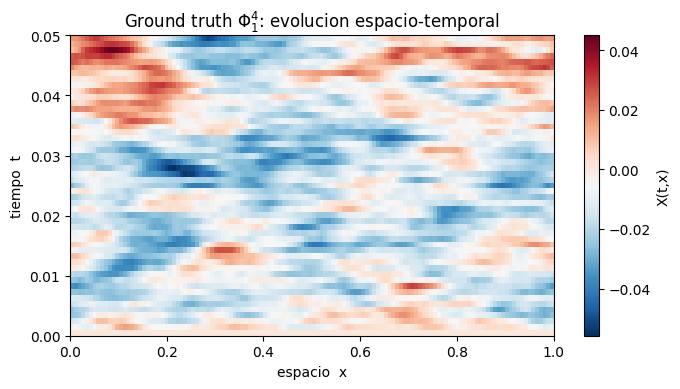

In [6]:
# Mapa de calor: eje x = espacio, eje y = tiempo
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(sol, aspect="auto", origin="lower", extent=[0, L, 0, T], cmap="RdBu_r")
ax.set_xlabel("espacio  x")
ax.set_ylabel("tiempo  t")
ax.set_title(r"Ground truth $\Phi^4_1$: evolucion espacio-temporal")
fig.colorbar(im, ax=ax, label="X(t,x)")
plt.tight_layout()
plt.savefig("phi41_heatmap.png", dpi=130)
plt.show()


## 6. Perfiles en instantes seleccionados

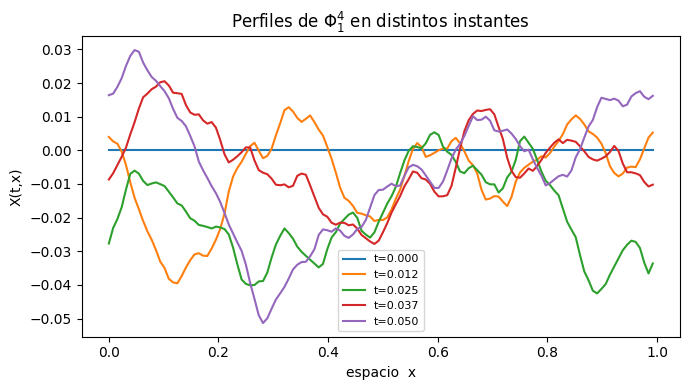

In [7]:
# Snapshots del campo a distintos tiempos (estilo Figure 3 del paper)
idx = [0, Nt // 4, Nt // 2, 3 * Nt // 4, Nt]
fig, ax = plt.subplots(figsize=(7, 4))
for i in idx:
    ax.plot(x, sol[i], label=f"t={i * dt:.3f}")
ax.set_xlabel("espacio  x")
ax.set_ylabel("X(t,x)")
ax.set_title(r"Perfiles de $\Phi^4_1$ en distintos instantes")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("phi41_perfiles.png", dpi=130)
plt.show()


## 7. Múltiples realizaciones (estructura estocástica)

La misma condición inicial con distintas semillas de ruido produce trayectorias distintas.
Esto ilustra por qué hace falta tratar la aleatoriedad explícitamente (motivación de WCE).


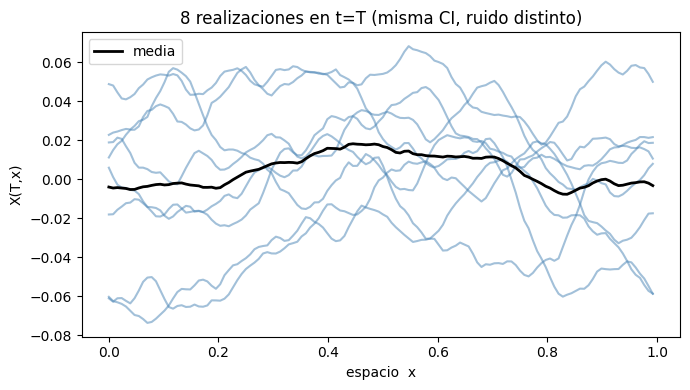

In [8]:
n_real = 8
finales = np.zeros((n_real, Nx))
for r in range(n_real):
    rng_r = np.random.default_rng(100 + r)
    finales[r] = resolver(ci_cero(), generar_ruido(rng_r))[-1]

fig, ax = plt.subplots(figsize=(7, 4))
for r in range(n_real):
    ax.plot(x, finales[r], color="steelblue", alpha=0.5)
ax.plot(x, finales.mean(axis=0), color="black", lw=2, label="media")
ax.set_xlabel("espacio  x")
ax.set_ylabel("X(T,x)")
ax.set_title(f"{n_real} realizaciones en t=T (misma CI, ruido distinto)")
ax.legend()
plt.tight_layout()
plt.savefig("phi41_realizaciones.png", dpi=130)
plt.show()


## 8. Generar un dataset (pares ruido -> solución)

Para conectar con el modelo F-SPDENO más adelante, el dataset es un conjunto de pares
$(W, X)$. Aquí generamos $N$ muestras y las guardamos. El paper usa $N=1000$ entrenamiento
+ 200 test; abajo se generan pocas como demostración (subir `N` para el dataset real).


In [9]:
def generar_dataset(N, seed=0, ci="cero", kappa=1.0):
    """Genera N trayectorias. Devuelve:
    W_all: ruido acumulado (N, Nt+1, Nx) -- util como entrada del modelo
    X_all: solucion        (N, Nt+1, Nx) -- objetivo."""
    rng = np.random.default_rng(seed)
    W_all = np.zeros((N, Nt + 1, Nx))
    X_all = np.zeros((N, Nt + 1, Nx))
    for i in range(N):
        dW = generar_ruido(rng)
        X0 = ci_cero() if ci == "cero" else ci_estocastica(rng, kappa)
        X_all[i] = resolver(X0, dW)
        W_all[i, 1:] = np.cumsum(dW, axis=0)  # ruido acumulado W(t,x)
    return W_all, X_all


# Demostracion con N pequeno (subir a 1000 para el dataset real)
N_demo = 20
W_all, X_all = generar_dataset(N_demo, seed=42)
print("W_all:", W_all.shape, "| X_all:", X_all.shape)

np.savez_compressed(
    "phi41_dataset_demo.npz", W=W_all, X=X_all, dx=dx, dt=dt, T=T, sigma=sigma
)
print("guardado: phi41_dataset_demo.npz")


W_all: (20, 51, 128) | X_all: (20, 51, 128)
guardado: phi41_dataset_demo.npz


In [10]:
# =====================================================================
# DATASET OFICIAL (tamaños del paper). Se genera aparte del demo.
# Crea dos datasets, uno por cada tarea de la Table 1:
#   - phi41_train_Wmap.npz   : tarea W -> X        (CI determinista, campo cero)
#   - phi41_train_X0Wmap.npz : tarea (X0,W) -> X   (CI estocastica)
# =====================================================================

N_TRAIN = 1000  # muestras de entrenamiento (paper)
N_TEST = 200  # muestras de test (paper); total 1200
N_TOTAL = N_TRAIN + N_TEST
KAPPA = 1.0  # regularidad de la CI estocastica (no especificado en el paper)

# Semillas fijas y SEPARADAS por split, para que train y test no compartan ruido.
SEED_TRAIN = 2024
SEED_TEST = 7777


def construir_split(N, seed, ci, kappa=KAPPA):
    # Envuelve generar_dataset y devuelve el par (W, X) con una semilla dada.
    return generar_dataset(N, seed=seed, ci=ci, kappa=kappa)


# --- Tarea 1: W -> X  (condicion inicial determinista) ---
Wtr, Xtr = construir_split(N_TRAIN, SEED_TRAIN, ci="cero")
Wte, Xte = construir_split(N_TEST, SEED_TEST, ci="cero")
np.savez_compressed(
    "phi41_train_Wmap.npz",
    W_train=Wtr,
    X_train=Xtr,
    W_test=Wte,
    X_test=Xte,
    dx=dx,
    dt=dt,
    T=T,
    sigma=sigma,
    N_train=N_TRAIN,
    N_test=N_TEST,
    seed_train=SEED_TRAIN,
    seed_test=SEED_TEST,
)
print("guardado phi41_train_Wmap.npz  | train:", Xtr.shape, "test:", Xte.shape)

# --- Tarea 2: (X0, W) -> X  (condicion inicial estocastica) ---
# Semillas distintas a las de la tarea 1 para no reutilizar exactamente los mismos ruidos.
Wtr2, Xtr2 = construir_split(N_TRAIN, SEED_TRAIN + 1, ci="estocastica")
Wte2, Xte2 = construir_split(N_TEST, SEED_TEST + 1, ci="estocastica")
np.savez_compressed(
    "phi41_train_X0Wmap.npz",
    W_train=Wtr2,
    X_train=Xtr2,
    W_test=Wte2,
    X_test=Xte2,
    dx=dx,
    dt=dt,
    T=T,
    sigma=sigma,
    kappa=KAPPA,
    N_train=N_TRAIN,
    N_test=N_TEST,
    seed_train=SEED_TRAIN + 1,
    seed_test=SEED_TEST + 1,
)
print("guardado phi41_train_X0Wmap.npz | train:", Xtr2.shape, "test:", Xte2.shape)

guardado phi41_train_Wmap.npz  | train: (1000, 51, 128) test: (200, 51, 128)
guardado phi41_train_X0Wmap.npz | train: (1000, 51, 128) test: (200, 51, 128)
